# The Study

Most research papers based on [NIH Chest X-rays](https://www.kaggle.com/datasets/nih-chest-xrays/data) Dataset does the following to achieve good results:
1. The most important trick is to use **Transfer Learing**, with very specific architectures and training tricks
2. The most sucessful model used for Chest X-ray classification is [DenseNet121](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.densenet121.html)
3. Using Models pretrained on [ImageNet](https://www.image-net.org/index.php) Dataset, and then replacing the last layer
4. Due to the imbalance in Class labels, they used [BCE Loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)
5. The evaluation is done using [AUROC](https://lightning.ai/docs/torchmetrics/stable/classification/auroc.html)
6. The **Augmentations** done on the collected Dataset is carefully performed
7. Since this is a **Multi-Label Classification**, they used **Sigmoid Function** instead of SoftMax
8. **Threshold Tuning** is also done to fine tune outputs
9. Training is done for only a *few epochs* (20 - 40 epochs)
10. Training is done through **Gradual Fine-tuning** a.k.a. *Layer Freezing and staged unfreezing*

# Install Libraries

The Required Libraries for the current process is loaded into the system by executing the following commands in a seperate python virtual environment's terminal:

```bash
pip install tqdm
pip install numpy
pip install pandas
pip install Pillow
pip install torch 
pip install torchvision 
pip install scikit-learn
```

The rest of the Libraries are already included in the python installation by default

# Importing Packages

In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import time
import os

In [2]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
import torch

In [3]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
from Datasets import ChestXrayDataset

# Import Dataset Splits

In [5]:
DATASET_PATH = "Dataset"
IMAGE_PATH = os.path.join(DATASET_PATH, "Images")

In [6]:
df = pd.read_csv(os.path.join(DATASET_PATH, "02. cleaned_dataset.csv"))

all_labels = set()
for labels_str in df["Finding Labels"]:
    for disease in labels_str.split("|"):
        all_labels.add(disease)

diseases = sorted(all_labels)

In [7]:
train_df = pd.read_csv("Dataset/03. train_df.csv")
val_df = pd.read_csv("Dataset/03. val_df.csv")
test_df = pd.read_csv("Dataset/03. test_df.csv")

# Importing Dataset Classes

In [8]:
# Slight Random Augmentations
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# No Augmentations
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# No Augmentations
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [9]:
train_dataset = ChestXrayDataset(
    train_df,
    IMAGE_PATH,
    diseases,
    transform=train_transforms
)

val_dataset = ChestXrayDataset(
    val_df,
    IMAGE_PATH,
    diseases,
    transform=val_transforms
)

test_dataset = ChestXrayDataset(
    test_df,
    IMAGE_PATH,
    diseases,
    transform=test_transforms
)

In [10]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0
)

# Checking Hardware

In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda") # For Nvidia GPUs
elif torch.backends.mps.is_available():
    device = torch.device("mps") # For Apple Silicon Chips
else:
    device = torch.device("cpu") # For Devices with no GPUs

print(device)

mps


# Loading Model

Here we load up the `DenseNet121` Model for the trining purposes. We do the following in this section:
- Load the `DenseNet1121` Model 
- Replace the Classifier of the Model
- Compute the Weights for the Imbalance of the Dataset
- Calculate the Loss Function
- Setup the Optimizer

In [12]:
model = models.densenet121(weights="DEFAULT")

In [13]:
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(diseases))
model = model.to(device)

In [14]:
class_counts = train_df[diseases].sum()
total_samples = len(train_df)

pos_weight = total_samples / class_counts
pos_weight = torch.tensor(pos_weight.values, dtype=torch.float32).to(device)

print(pos_weight)

tensor([ 11.8634,  53.7043,  35.9317,  97.9314,  13.3722,  49.6965,  44.3956,
        499.4500,   7.4378,  34.9266,   1.5858,  24.5430,  36.8598, 101.9286,
         30.1782], device='mps:0')


In [15]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Training Functions

In [16]:
def train_epoch(model, loader, optimizer):
    start = time.time()

    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return [total_loss / len(loader), round(time.time() - start, 2)]

In [17]:
def validate_epoch(model, loader):
    start = time.time()

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return [total_loss / len(loader), round(time.time() - start, 2)]

In [18]:
num_epochs = 20
patience = 3

# Training & Validation - Stage 1

In [19]:
for param in model.features.parameters():
    param.requires_grad = False

In [20]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_out = train_epoch(model, train_loader, optimizer)
    val_out = validate_epoch(model, val_loader)

    print(f"Train Loss: {train_out[0]:.4f}")
    print(f"Train Time: {train_out[1]:.2f}")
    print(f"Val Loss: {val_out[0]:.4f}")
    print(f"Val Time: {val_out[1]:.2f}")
    
    train_losses.append(train_out[0])
    val_losses.append(val_out[0])

    # Check improvement
    if val_out[0] < best_val_loss:
        best_val_loss = val_out[0]
        patience_counter = 0
        
        torch.save(model.state_dict(), "Models/best_model.pth")
        print("Model improved and saved!")

    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")

    # Early stopping condition
    if patience_counter >= patience:
        print("Early stopping triggered")
        break
    
    print()

Epoch 1/20


100%|██████████| 80/80 [00:41<00:00,  1.92it/s]


Train Loss: 1.3330
Train Time: 169.20
Val Loss: 1.3809
Val Time: 41.69
Model improved and saved!

Epoch 2/20


100%|██████████| 80/80 [00:40<00:00,  1.99it/s]


Train Loss: 1.3145
Train Time: 180.84
Val Loss: 1.3591
Val Time: 40.29
Model improved and saved!

Epoch 3/20


...

Train Loss: 1.1705
Train Time: 169.86
Val Loss: 1.2661
Val Time: 38.08
No improvement for 1 epochs

Epoch 15/20


100%|██████████| 80/80 [00:41<00:00,  1.94it/s]


Train Loss: 1.1728
Train Time: 181.15
Val Loss: 1.2673
Val Time: 41.21
No improvement for 2 epochs

Epoch 16/20


100%|██████████| 80/80 [00:41<00:00,  1.95it/s]

Train Loss: 1.1662
Train Time: 181.43
Val Loss: 1.2703
Val Time: 41.05
No improvement for 3 epochs
Early stopping triggered


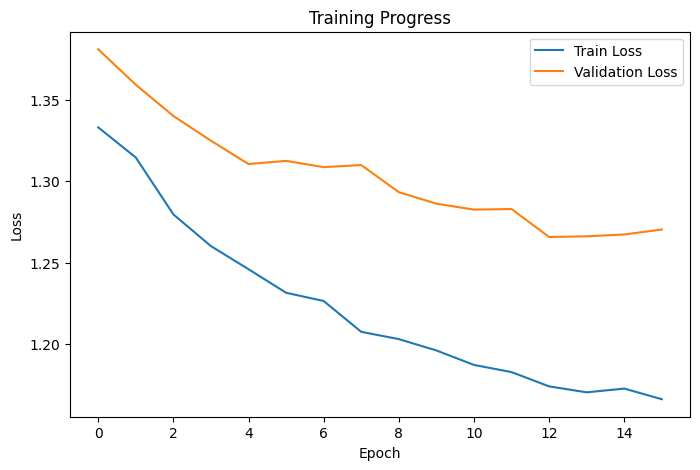

In [22]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Progress")

plt.legend()
plt.show()

# Training & Validation - Stage 2

In [23]:
for param in model.features.parameters():
    param.requires_grad = True

In [24]:
optimizer = optim.Adam(
    model.parameters(), 
    lr=1e-5
)

In [ ]:
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_out = train_epoch(model, train_loader, optimizer)
    val_out = validate_epoch(model, val_loader)

    print(f"Train Loss: {train_out[0]:.4f}")
    print(f"Train Time: {train_out[1]:.2f}")
    print(f"Val Loss: {val_out[0]:.4f}")
    print(f"Val Time: {val_out[1]:.2f}")
    
    train_losses.append(train_out[0])
    val_losses.append(val_out[0])

    # Check improvement
    if val_out[0] < best_val_loss:
        best_val_loss = val_out[0]
        patience_counter = 0
        
        torch.save(model.state_dict(), "Models/best_model.pth")
        print("Model improved and saved!")

    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")

    # Early stopping condition
    if patience_counter >= patience:
        print("Early stopping triggered")
        break
    
    print()

Epoch 1/20


100%|██████████| 80/80 [00:38<00:00,  2.10it/s]


Train Loss: 1.1377
Train Time: 366.02
Val Loss: 1.2334
Val Time: 38.19
Model improved and saved!

Epoch 2/20


100%|██████████| 80/80 [00:40<00:00,  1.98it/s]


Train Loss: 1.0983
Train Time: 365.26
Val Loss: 1.2206
Val Time: 40.46
Model improved and saved!

Epoch 3/20


...

Train Loss: 0.9469
Train Time: 341.33
Val Loss: 1.1993
Val Time: 38.58
No improvement for 1 epochs

Epoch 9/20


100%|██████████| 80/80 [00:41<00:00,  1.93it/s]


Train Loss: 0.9248
Train Time: 362.45
Val Loss: 1.2007
Val Time: 41.38
No improvement for 2 epochs

Epoch 10/20


100%|██████████| 80/80 [00:39<00:00,  2.00it/s]

Train Loss: 0.9077
Train Time: 387.16
Val Loss: 1.2022
Val Time: 39.96
No improvement for 3 epochs
Early stopping triggered


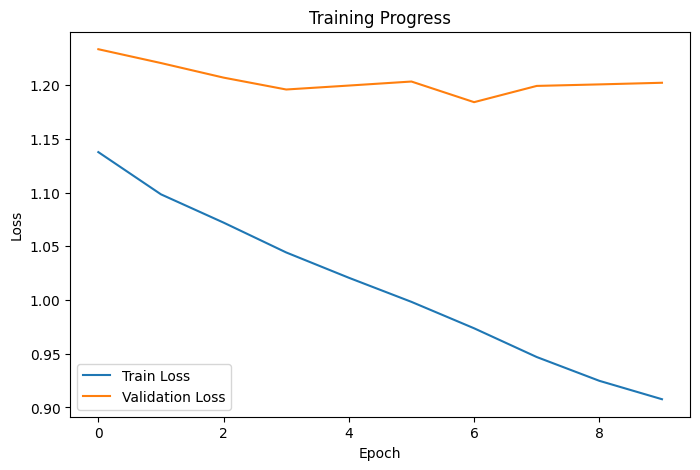

In [26]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Progress")

plt.legend()
plt.show()

# Saving Final Model

In [ ]:
torch.save(model.state_dict(), "Models/final_model.pth")

# Test

In [28]:
images, labels = next(iter(test_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = torch.sigmoid(outputs)

print(probs[0])

tensor([0.5473, 0.3987, 0.2502, 0.0297, 0.2215, 0.5648, 0.6500, 0.7526, 0.5367,
        0.4084, 0.7625, 0.5761, 0.4244, 0.1996, 0.3185], device='mps:0')
